### [GitHub](https://github.com/msultanmahmud/Stress_WESAD/blob/master/Multiclass_Pipeline_Individual_sub_INTEC.ipynb)

In [60]:
import numpy as np
import pandas as pd

In [2]:
# ! pip list

In [3]:
# ! pip install lightgbm

In [7]:
import numpy as np
import pandas as pd
import os
import sys
import random
import warnings
warnings.filterwarnings('ignore')
import pickle
from sklearn.model_selection import train_test_split
from sklearn import svm, metrics,preprocessing
#from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,roc_curve, auc,classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_predict
from matplotlib import pyplot as plt
from collections import Counter
from scipy.stats import norm
import seaborn as sns; sns.set(font_scale=1.2)
%matplotlib inline
import time
import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#### Redaing file

In [9]:
# with open("wsc_visit1_allsub.pkl", "rb") as f:
#     df = pickle.load(f)
#     df=df.sort_values(by='subject')

In [10]:
df=pd.read_csv('../dreamt_preprocessed.csv')
df.subject.nunique()

100

In [11]:
print(df.shape)

(95147, 289)


In [12]:
# Identify columns to drop if they exist
columns_to_drop = [col for col in df.columns if 'skewness' in col.lower() or 'kurtosis' in col.lower()]

# Drop only those columns that actually exist
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
df 

,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,HR_p95,IBI_min,IBI_max,IBI_mean,IBI_std,IBI_p5,IBI_p25,IBI_p50,IBI_p75,IBI_p95
0,S002,1,3.0,-0.000008,0.000008,6.380306e-09,0.000002,-0.000004,-1.318379e-06,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
1,S002,2,3.0,-0.000006,0.000005,4.531319e-08,0.000002,-0.000003,-1.123064e-06,-4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
2,S002,3,3.0,-0.000004,0.000005,4.547595e-08,0.000002,-0.000002,-9.277485e-07,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
3,S002,4,3.0,-0.000017,0.000019,6.071056e-08,0.000003,-0.000004,-1.220722e-06,1.464866e-07,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
4,S002,5,3.0,-0.000008,0.000009,6.067801e-08,0.000002,-0.000004,-1.416037e-06,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95142,S103,899,1.0,-0.000025,0.000045,2.679077e-08,0.000008,-0.000012,-4.638743e-06,-1.464866e-07,...,72.12,0.859375,0.906250,0.884599,0.016580,0.859375,0.859375,0.890625,0.890625,0.906250
95143,S103,900,1.0,-0.000035,0.000032,1.027685e-07,0.000008,-0.000014,-4.638743e-06,1.464866e-07,...,68.87,0.812500,0.890625,0.869016,0.019533,0.828125,0.859375,0.859375,0.890625,0.890625
95144,S103,901,1.0,-0.000083,0.000080,1.070654e-07,0.000011,-0.000013,-4.541085e-06,3.906310e-07,...,69.03,0.843750,0.906250,0.871021,0.019181,0.843750,0.859375,0.875000,0.875000,0.906250
95145,S103,902,1.0,-0.000049,0.000056,8.274866e-08,0.000009,-0.000013,-4.931716e-06,1.464866e-07,...,69.42,0.734375,0.937500,0.869594,0.061489,0.734375,0.875000,0.890625,0.906250,0.921875


## Taking the cleaned final data

In [19]:
df = df[~df['subject'].isin(['S062', 'S097'])]
pre_procss_all=df.copy()
pre_procss_all

,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,HR_p95,IBI_min,IBI_max,IBI_mean,IBI_std,IBI_p5,IBI_p25,IBI_p50,IBI_p75,IBI_p95
0,S002,1,3.0,-0.000008,0.000008,6.380306e-09,0.000002,-0.000004,-1.318379e-06,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
1,S002,2,3.0,-0.000006,0.000005,4.531319e-08,0.000002,-0.000003,-1.123064e-06,-4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
2,S002,3,3.0,-0.000004,0.000005,4.547595e-08,0.000002,-0.000002,-9.277485e-07,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
3,S002,4,3.0,-0.000017,0.000019,6.071056e-08,0.000003,-0.000004,-1.220722e-06,1.464866e-07,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
4,S002,5,3.0,-0.000008,0.000009,6.067801e-08,0.000002,-0.000004,-1.416037e-06,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95142,S103,899,1.0,-0.000025,0.000045,2.679077e-08,0.000008,-0.000012,-4.638743e-06,-1.464866e-07,...,72.12,0.859375,0.906250,0.884599,0.016580,0.859375,0.859375,0.890625,0.890625,0.906250
95143,S103,900,1.0,-0.000035,0.000032,1.027685e-07,0.000008,-0.000014,-4.638743e-06,1.464866e-07,...,68.87,0.812500,0.890625,0.869016,0.019533,0.828125,0.859375,0.859375,0.890625,0.890625
95144,S103,901,1.0,-0.000083,0.000080,1.070654e-07,0.000011,-0.000013,-4.541085e-06,3.906310e-07,...,69.03,0.843750,0.906250,0.871021,0.019181,0.843750,0.859375,0.875000,0.875000,0.906250
95145,S103,902,1.0,-0.000049,0.000056,8.274866e-08,0.000009,-0.000013,-4.931716e-06,1.464866e-07,...,69.42,0.734375,0.937500,0.869594,0.061489,0.734375,0.875000,0.890625,0.906250,0.921875


In [21]:
# list(pre_procss_all.columns)

In [23]:
# ch=(237-3)/9
26*9

234

## >>>>>> PSG DATA Separation done <<<<<<<<<<<<

### Here only keeping the 3 classses (Wake, Non-REM, and REM) data 
- "df_fusion_cleaned" from this claen data the selected feature will be extarcted

In [27]:
wanted_keywords = ['BVP', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR', 'IBI']
pattern = '|'.join(wanted_keywords)
 
# Select columns that do NOT match the regex pattern
df_psg = pre_procss_all.loc[:, ~pre_procss_all.columns.str.contains(pattern, case=False, regex=True)]
df_psg
# Drop columns with any null (NaN) values
df_psg_cleaned = df_psg.dropna(axis=1, how='any')
# Optionally: print removed columns
psg_removed_cols = df_psg.columns[df_psg.isnull().any()].tolist()
print("Removed columns with nulls:", psg_removed_cols)
df_psg_cleaned
 
df_psg_cleaned = df_psg_cleaned[df_psg_cleaned['label'].isin([0,1,2])]
df_psg_cleaned.head(3)

Removed columns with nulls: []


,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,RAT_p95,SAO2_min,SAO2_max,SAO2_mean,SAO2_std,SAO2_p5,SAO2_p25,SAO2_p50,SAO2_p75,SAO2_p95
305,S002,307,0.0,-0.000043,0.000020,-2.770550e-07,0.000007,-0.000010,-0.000003,4.394598e-07,...,0.000007,0.969907,0.969941,0.969924,0.000006,0.969915,0.969919,0.969924,0.969930,0.969934
306,S002,308,0.0,-0.000018,0.000014,6.477963e-09,0.000005,-0.000007,-0.000003,4.882887e-08,...,0.000005,0.958276,0.971334,0.966985,0.004638,0.959652,0.959699,0.969916,0.969931,0.969956
307,S002,309,0.0,-0.000050,0.000046,2.981816e-08,0.000008,-0.000011,-0.000003,2.441444e-07,...,0.000006,0.969916,0.969933,0.969924,0.000004,0.969918,0.969920,0.969924,0.969929,0.969931


In [29]:
# df_fusion_cleaned = pre_procss_all[pre_procss_all['label'].isin([0,1,2])]
# df_fusion_cleaned.head(3)

# ### How many subjec
# # sample=df.subject.unique()[:5]
# # # # Sample the data (if needed)
# # df_sample = df[df.subject.isin(sample)]
# # df_sample

In [31]:
# df1=df_fusion_cleaned.copy()
# df1=df_fusion_cleaned.head(1000)
df=df_psg_cleaned.copy()

### Reading the stability score pickle.

In [34]:
# with open("results_ss_v1.pkl", "rb") as f:
with open("stability_score_alpha_psg_v1.pkl", "rb") as f:
    results = pickle.load(f)
results.keys()

dict_keys([0.001, 0.01, 0.02, 0.04, 0.05, 0.07])

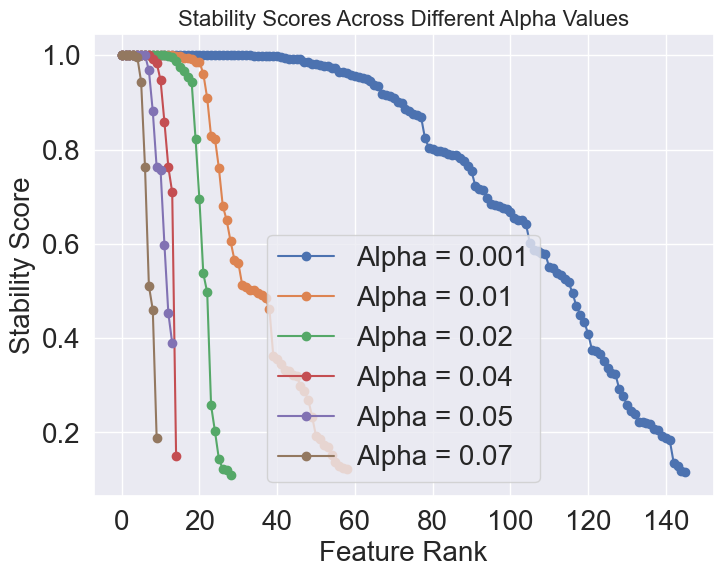

In [36]:
# Plot stability scores for each alpha
fs=20
plt.figure(figsize=(8, 6))

for alpha, df_alpha in results.items():
    filtered_df = df_alpha[df_alpha['Stability_Score'] >= 0.1]
    plt.plot(range(len(filtered_df)), filtered_df['Stability_Score'], label=f'Alpha = {alpha}', marker='o')

plt.title('Stability Scores Across Different Alpha Values',fontsize=16)
plt.xlabel('Feature Rank',fontsize=fs)
plt.ylabel('Stability Score',fontsize=fs)
plt.xticks(fontsize=fs)  # Make x-axis tick labels larger
plt.yticks(fontsize=fs)  # Make y-axis tick labels larger
plt.legend(fontsize=fs,loc='lower center')
plt.grid(True)
plt.show()

In [62]:
alpha=0.01;
sc=0.9;
feature_importance_df_07=results[alpha][results[alpha].Stability_Score>=sc]['Feature'].values
sel_col=np.append(feature_importance_df_07,'label')
### Selected features only
df_sel=df_psg_cleaned [sel_col]
df_sel.head(3)

,ECG_min,PTAF_p25,RAT_max,F4-M1_p50,CHIN_p25,ECG_p50,SNORE_min,PTAF_max,PTAF_p75,FLOW_max,...,FP1-O2_std,ABDOMEN_max,ECG_p75,E2_p75,THORAX_p25,SAO2_mean,LAT_min,LAT_max,LAT_p75,label
305,-0.000207,-0.001435,0.000047,5.371176e-07,-0.000004,-0.000007,-0.000060,0.003166,-0.000341,0.000063,...,0.000018,0.000736,0.000027,0.000006,-0.000507,0.969924,-0.000070,0.000067,0.000005,0.0
306,-0.000223,-0.001557,0.000012,1.464866e-07,-0.000004,-0.000005,-0.000007,0.003147,-0.000843,0.000072,...,0.000010,0.001070,0.000024,0.000005,-0.000873,0.966985,-0.000010,0.000010,0.000005,0.0
307,-0.000250,-0.001517,0.000019,-4.882887e-08,-0.000004,-0.000005,-0.000021,0.003180,-0.000877,0.000066,...,0.000014,0.000878,0.000026,0.000006,-0.000749,0.969924,-0.000011,0.000010,0.000006,0.0


In [64]:
df_sel

,ECG_min,PTAF_p25,RAT_max,F4-M1_p50,CHIN_p25,ECG_p50,SNORE_min,PTAF_max,PTAF_p75,FLOW_max,...,FP1-O2_std,ABDOMEN_max,ECG_p75,E2_p75,THORAX_p25,SAO2_mean,LAT_min,LAT_max,LAT_p75,label
305,-0.000207,-0.001435,0.000047,5.371176e-07,-0.000004,-0.000007,-0.000060,0.003166,-0.000341,0.000063,...,0.000018,0.000736,0.000027,0.000006,-0.000507,0.969924,-0.000070,0.000067,5.420005e-06,0.0
306,-0.000223,-0.001557,0.000012,1.464866e-07,-0.000004,-0.000005,-0.000007,0.003147,-0.000843,0.000072,...,0.000010,0.001070,0.000024,0.000005,-0.000873,0.966985,-0.000010,0.000010,5.127031e-06,0.0
307,-0.000250,-0.001517,0.000019,-4.882887e-08,-0.000004,-0.000005,-0.000021,0.003180,-0.000877,0.000066,...,0.000014,0.000878,0.000026,0.000006,-0.000749,0.969924,-0.000011,0.000010,5.810636e-06,0.0
308,-0.000198,-0.001292,0.000016,-4.882887e-08,-0.000004,-0.000006,-0.000007,0.002983,-0.000649,0.000057,...,0.000013,0.000935,0.000026,0.000005,-0.000791,0.969924,-0.000024,0.000029,5.322347e-06,0.0
309,-0.001434,-0.001336,0.000133,5.371176e-07,-0.000004,-0.000005,-0.000036,0.003143,-0.000585,0.000091,...,0.000014,0.000929,0.000056,0.000006,-0.000557,0.969924,-0.000073,0.000045,5.517662e-06,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95142,-0.000938,-0.000089,0.000009,4.882887e-08,-0.000002,0.000033,-0.000057,0.001244,0.000026,0.000433,...,0.000012,0.000345,0.000049,0.000004,-0.000125,0.914902,-0.000031,0.000060,8.300908e-07,1.0
95143,-0.000972,-0.000196,0.000053,-1.464866e-07,-0.000002,0.000033,-0.000042,0.002186,0.000049,0.000614,...,0.000015,0.000528,0.000050,0.000005,-0.000156,0.926600,-0.000049,0.000116,1.123064e-06,1.0
95144,-0.000965,-0.000120,0.000009,2.441444e-07,-0.000002,0.000032,-0.000028,0.000935,0.000039,0.000320,...,0.000017,0.000334,0.000048,0.000004,-0.000157,0.929748,-0.000024,0.000020,7.324331e-07,1.0
95145,-0.000958,-0.000097,0.000009,2.441444e-07,-0.000002,0.000033,-0.000030,0.001406,0.000021,0.000299,...,0.000014,0.000230,0.000050,0.000004,-0.000166,0.917330,-0.000017,0.000009,7.324331e-07,1.0


### Apply PCA here

In [66]:
df_sel

,ECG_min,PTAF_p25,RAT_max,F4-M1_p50,CHIN_p25,ECG_p50,SNORE_min,PTAF_max,PTAF_p75,FLOW_max,...,FP1-O2_std,ABDOMEN_max,ECG_p75,E2_p75,THORAX_p25,SAO2_mean,LAT_min,LAT_max,LAT_p75,label
305,-0.000207,-0.001435,0.000047,5.371176e-07,-0.000004,-0.000007,-0.000060,0.003166,-0.000341,0.000063,...,0.000018,0.000736,0.000027,0.000006,-0.000507,0.969924,-0.000070,0.000067,5.420005e-06,0.0
306,-0.000223,-0.001557,0.000012,1.464866e-07,-0.000004,-0.000005,-0.000007,0.003147,-0.000843,0.000072,...,0.000010,0.001070,0.000024,0.000005,-0.000873,0.966985,-0.000010,0.000010,5.127031e-06,0.0
307,-0.000250,-0.001517,0.000019,-4.882887e-08,-0.000004,-0.000005,-0.000021,0.003180,-0.000877,0.000066,...,0.000014,0.000878,0.000026,0.000006,-0.000749,0.969924,-0.000011,0.000010,5.810636e-06,0.0
308,-0.000198,-0.001292,0.000016,-4.882887e-08,-0.000004,-0.000006,-0.000007,0.002983,-0.000649,0.000057,...,0.000013,0.000935,0.000026,0.000005,-0.000791,0.969924,-0.000024,0.000029,5.322347e-06,0.0
309,-0.001434,-0.001336,0.000133,5.371176e-07,-0.000004,-0.000005,-0.000036,0.003143,-0.000585,0.000091,...,0.000014,0.000929,0.000056,0.000006,-0.000557,0.969924,-0.000073,0.000045,5.517662e-06,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95142,-0.000938,-0.000089,0.000009,4.882887e-08,-0.000002,0.000033,-0.000057,0.001244,0.000026,0.000433,...,0.000012,0.000345,0.000049,0.000004,-0.000125,0.914902,-0.000031,0.000060,8.300908e-07,1.0
95143,-0.000972,-0.000196,0.000053,-1.464866e-07,-0.000002,0.000033,-0.000042,0.002186,0.000049,0.000614,...,0.000015,0.000528,0.000050,0.000005,-0.000156,0.926600,-0.000049,0.000116,1.123064e-06,1.0
95144,-0.000965,-0.000120,0.000009,2.441444e-07,-0.000002,0.000032,-0.000028,0.000935,0.000039,0.000320,...,0.000017,0.000334,0.000048,0.000004,-0.000157,0.929748,-0.000024,0.000020,7.324331e-07,1.0
95145,-0.000958,-0.000097,0.000009,2.441444e-07,-0.000002,0.000033,-0.000030,0.001406,0.000021,0.000299,...,0.000014,0.000230,0.000050,0.000004,-0.000166,0.917330,-0.000017,0.000009,7.324331e-07,1.0


In [68]:
## separating the Features and class labels
X = df_sel.drop(columns=['label'], axis=1)
y = df_sel["label"]

In [70]:
# Standardize the data
X_std = StandardScaler().fit_transform(X)

# Apply PCA
X_pca = PCA(n_components=2).fit_transform(X_std)

# Combine PCA components with class labels
X_pca = np.hstack((X_pca, y.values.reshape(-1, 1)))

# Create DataFrame
df_pca = pd.DataFrame(X_pca, columns=['1st_Component', '2nd_Component', 'class'])

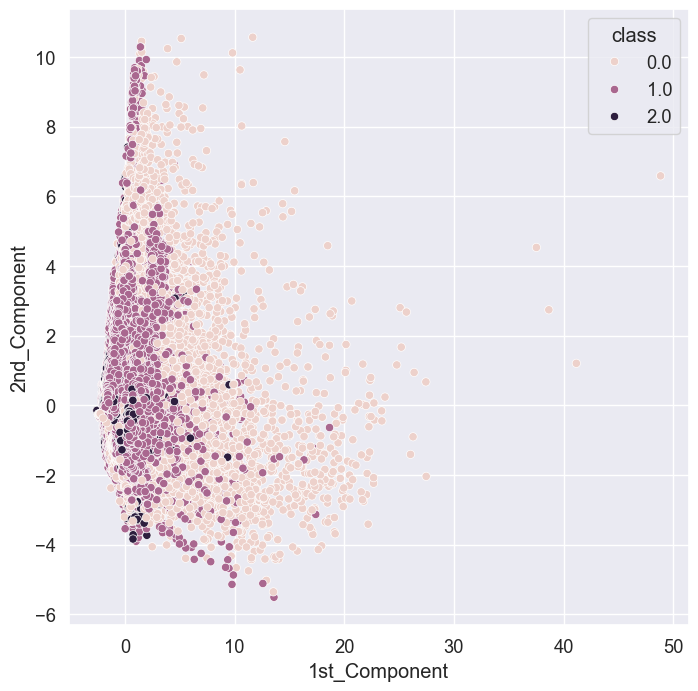

In [72]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df_pca, hue="class", x="1st_Component", y="2nd_Component")
plt.show()

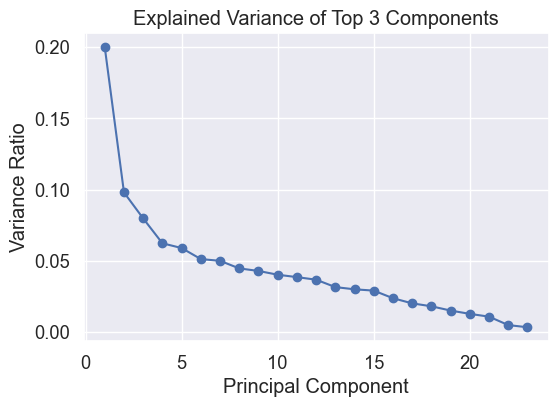

In [73]:
# 1. Separate features and labels
X = df_sel.drop(columns=['label'], axis=1)
y = df_sel['label']

# 2. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
n_com=df_sel.shape[1]-1 #17
# 3. Apply PCA (retain top 3 components)
pca = PCA(n_components=n_com)
X_pca = pca.fit_transform(X_scaled)

# Optional: Visualize the explained variance
plt.figure(figsize=(6,4))
plt.plot(range(1,n_com+1 ), pca.explained_variance_ratio_, marker='o')
plt.title("Explained Variance of Top 3 Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.grid(True)
plt.show()

In [76]:
np.cumsum(pca.explained_variance_ratio_[:17])

array([0.20008673, 0.29807987, 0.3777804 , 0.44000192, 0.49887818,
       0.54999186, 0.5998748 , 0.64442906, 0.68719807, 0.72731406,
       0.76574016, 0.80235316, 0.83376585, 0.86361671, 0.89255581,
       0.91614455, 0.93611177])

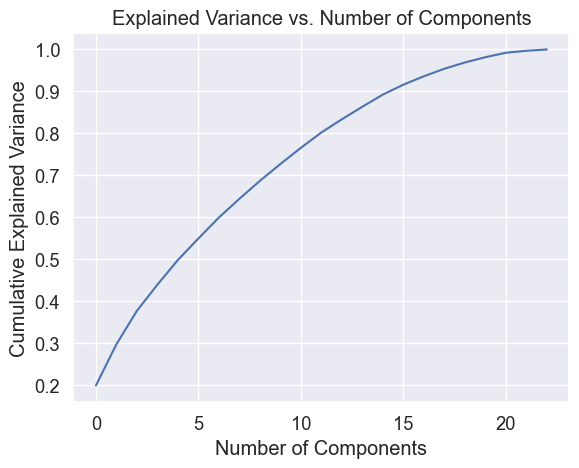

In [78]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of Components")
plt.grid(True)
plt.show()


### t-SNE

In [80]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X_std)
X_tsne_data = np.vstack((X_tsne.T, y)).T
df_tsne = pd.DataFrame(X_tsne_data, columns=["Dim1", "Dim2", "class"])
df_tsne.head()

,Dim1,Dim2,class
0,64.603981,53.409386,0.0
1,65.167000,53.929924,0.0
2,65.214737,53.889645,0.0
3,65.119888,53.862797,0.0
4,65.977051,53.693031,0.0


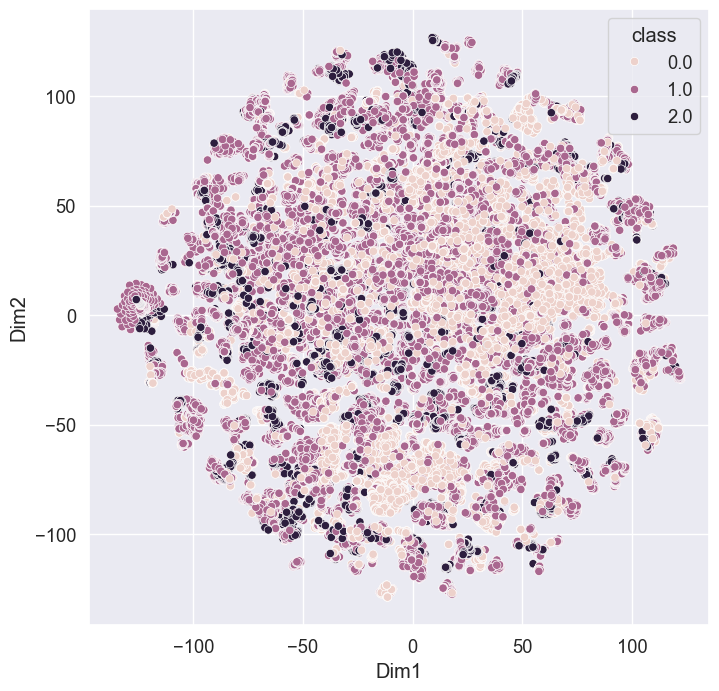

In [81]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df_tsne, hue="class", x="Dim1", y="Dim2")
plt.show()

In [82]:
X_pca

array([[ 1.26721097e+00,  1.02482958e+00, -1.65103285e+00, ...,
         2.44600743e-01,  3.30707599e-01, -3.95252732e-02],
       [ 1.21732957e+00, -4.52351082e-01, -2.86350078e+00, ...,
         1.34069398e+00,  4.79386864e-01, -3.42187741e-02],
       [ 1.10876588e+00, -3.52190931e-01, -2.30780734e+00, ...,
         1.10874183e+00,  3.16419418e-01, -3.55614794e-02],
       ...,
       [ 3.39442925e-01, -5.98891614e-01,  8.36808245e-01, ...,
         7.23254451e-01,  1.25629826e-01, -4.57116058e-02],
       [ 5.29132031e-01, -5.15261696e-01,  6.66520538e-01, ...,
         5.77830449e-01,  2.35140618e-03, -6.13517699e-02],
       [ 3.12530425e+00, -3.11859313e-01,  5.03337172e-01, ...,
         6.22997327e-01, -2.13108245e-01,  1.65533611e-01]])

#### Making the data as PCA

In [84]:
# 1. Separate features and labels
X = df_sel.drop(columns=['label'], axis=1)
y = df_sel['label']

# 2. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
n_com=df_sel.shape[1]-6 #17
# 3. Apply PCA (retain top 3 components)
pca = PCA(n_components=n_com)
X_pca = pca.fit_transform(X_scaled)

# 4. Convert PCA output to DataFrame
pca_columns = [f'PC{i+1}' for i in range(n_com)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)

# 5. Align indices and concatenate with labels
X_pca_df.reset_index(drop=True, inplace=True)
y.reset_index(drop=True, inplace=True)
df_pca = pd.concat([X_pca_df, y], axis=1)
df_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,label
0,1.267211,1.024830,-1.651033,0.053750,-1.891675,-1.949545,0.079039,0.990555,0.289062,-0.247442,0.720192,0.321538,0.446140,-0.010964,1.211758,-0.374794,1.522609,-3.154504,0.0
1,1.217330,-0.452351,-2.863501,0.649373,-2.794450,-2.186505,-0.233238,1.130607,0.623047,-0.605353,0.961680,0.507803,0.696242,0.021061,1.719391,-0.434366,2.348078,-4.540445,0.0
2,1.108766,-0.352191,-2.307807,0.737462,-2.429433,-2.010736,-0.244785,0.957184,0.465009,-0.546903,0.906493,0.470007,0.679221,-0.032311,1.675833,-0.506512,2.491604,-4.632535,0.0
3,1.117049,-0.302362,-2.493765,0.716214,-2.741316,-1.985548,-0.176559,1.041349,0.518636,-0.583699,0.943939,0.326789,0.550410,0.039538,1.493317,-0.322683,1.841192,-3.748314,0.0
4,2.961616,-0.025136,-1.643065,1.663864,-1.442668,-2.479913,-0.282719,1.372060,-1.191447,-0.481555,0.111967,0.743087,1.717512,-0.343696,0.107771,-0.899598,2.140075,-3.771622,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70150,0.668461,-0.652933,0.613786,1.311056,0.604924,-2.724676,-0.331627,-0.518260,-2.177125,-0.511990,0.797036,0.800091,1.482489,0.598815,0.762324,0.230594,-0.439893,-0.148967,1.0
70151,1.348666,-0.188552,0.353774,1.116725,0.774119,-2.812065,-0.665916,-0.435716,-1.934207,-0.451290,0.711174,0.852633,1.506849,0.646645,0.897474,0.184925,-0.314080,-0.481683,1.0
70152,0.339443,-0.598892,0.836808,1.367305,0.785732,-2.633907,-0.373269,-0.532357,-2.189237,-0.392526,0.652490,0.964377,1.512719,0.436454,0.614544,0.101190,-0.520969,0.001023,1.0
70153,0.529132,-0.515262,0.666521,1.436922,0.614601,-2.804783,-0.309608,-0.460493,-2.197449,-0.502711,0.801327,0.922910,1.463492,0.458153,0.719015,0.199003,-0.408140,-0.194553,1.0


In [85]:
X = df_pca.drop(columns=['label'])
X

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
0,1.267211,1.024830,-1.651033,0.053750,-1.891675,-1.949545,0.079039,0.990555,0.289062,-0.247442,0.720192,0.321538,0.446140,-0.010964,1.211758,-0.374794,1.522609,-3.154504
1,1.217330,-0.452351,-2.863501,0.649373,-2.794450,-2.186505,-0.233238,1.130607,0.623047,-0.605353,0.961680,0.507803,0.696242,0.021061,1.719391,-0.434366,2.348078,-4.540445
2,1.108766,-0.352191,-2.307807,0.737462,-2.429433,-2.010736,-0.244785,0.957184,0.465009,-0.546903,0.906493,0.470007,0.679221,-0.032311,1.675833,-0.506512,2.491604,-4.632535
3,1.117049,-0.302362,-2.493765,0.716214,-2.741316,-1.985548,-0.176559,1.041349,0.518636,-0.583699,0.943939,0.326789,0.550410,0.039538,1.493317,-0.322683,1.841192,-3.748314
4,2.961616,-0.025136,-1.643065,1.663864,-1.442668,-2.479913,-0.282719,1.372060,-1.191447,-0.481555,0.111967,0.743087,1.717512,-0.343696,0.107771,-0.899598,2.140075,-3.771622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70150,0.668461,-0.652933,0.613786,1.311056,0.604924,-2.724676,-0.331627,-0.518260,-2.177125,-0.511990,0.797036,0.800091,1.482489,0.598815,0.762324,0.230594,-0.439893,-0.148967
70151,1.348666,-0.188552,0.353774,1.116725,0.774119,-2.812065,-0.665916,-0.435716,-1.934207,-0.451290,0.711174,0.852633,1.506849,0.646645,0.897474,0.184925,-0.314080,-0.481683
70152,0.339443,-0.598892,0.836808,1.367305,0.785732,-2.633907,-0.373269,-0.532357,-2.189237,-0.392526,0.652490,0.964377,1.512719,0.436454,0.614544,0.101190,-0.520969,0.001023
70153,0.529132,-0.515262,0.666521,1.436922,0.614601,-2.804783,-0.309608,-0.460493,-2.197449,-0.502711,0.801327,0.922910,1.463492,0.458153,0.719015,0.199003,-0.408140,-0.194553


In [86]:
# df1=df_sample.copy()

In [87]:
# !jupyter kernelspec list

In [88]:
from joblib import Parallel, delayed
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import xgboost as xgb
import lightgbm as lgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
import pandas as pd
import numpy as np

def preprocess_scaling(df):
    '''Scales features and splits into train/test.'''
    # X = df.drop(columns=['subject', 'epoch', 'label'])
    X = df.drop(columns=['label'])
    y = df['label']
    X_scaled = preprocessing.scale(X)
    return train_test_split(X_scaled, y, test_size=0.2, random_state=42)

def train_and_evaluate(model, X_train, y_train, X_test, y_test, model_name, auc_mode='ovr'):
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

        # AUC calculation — multi-class
        if hasattr(model, "predict_proba"):
            y_probs = model.predict_proba(X_test)
            auc = roc_auc_score(y_test, y_probs, multi_class=auc_mode, average='macro')
        else:
            auc = None  # SVM without probability=True will not support this

        return (model_name, acc, f1, precision, recall, auc)
    except Exception as e:
        print(f"Error with model {model_name}: {e}")
        return (model_name, None, None, None, None, None)

def multiple_model(df, auc_mode='ovr'):
    X_train, X_test, y_train, y_test = preprocess_scaling(df)
    model_name_list = ['KNN', 'DT', 'XGBoost', 'LightGBM', 'RF', 'SVM']

    # SVM needs probability=True for predict_proba
    models = [
        KNeighborsClassifier(metric='minkowski', n_neighbors=2, weights='distance', p=2),
        DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=50),
        xgb.XGBClassifier(objective='multi:softprob', num_class=len(np.unique(y_train)), random_state=42,
                          max_depth=15, learning_rate=0.3, gamma=0.2, colsample_bytree=0.7,
                          min_child_weight=1, eval_metric='mlogloss', n_jobs=-1),
        lgb.LGBMClassifier(colsample_bytree=0.7, learning_rate=0.3, max_depth=100,
                           min_child_weight=0.5, n_estimators=200, verbose=-1, n_jobs=-1),
        RandomForestClassifier(max_depth=40, max_features='log2', n_estimators=200, n_jobs=-1),
        svm.SVC(C=10, kernel='rbf', degree=3, gamma=0.1, probability=True)  # Required for AUC
    ]

    results_list = Parallel(n_jobs=-1)(delayed(train_and_evaluate)(
        model, X_train, y_train, X_test, y_test, name, auc_mode
    ) for model, name in zip(models, model_name_list))

    results_df = pd.DataFrame(results_list, columns=['Model', 'Accuracy', 'F1', 'Precision', 'Recall', 'AUC'])
    results_df.set_index('Model', inplace=True)
    results_df=results_df[['Accuracy','AUC','Precision', 'Recall','F1']]
    return results_df

In [89]:
# # Default AUC = 'ovr'
# results = multiple_model(df1)
# results

In [90]:
# # Or try one-vs-one AUC if OvR seems low
# results_ovo = multiple_model(df1, auc_mode='ovo')
# results_ovo

### Ensemble Learning

In [93]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm

def ensemble_model(df, voting_type='hard', auc_mode='ovr'):
    X_train, X_test, y_train, y_test = preprocess_scaling(df)

    # Define base models
    knn = KNeighborsClassifier(metric='minkowski', n_neighbors=2, weights='distance', p=2)
    dt = DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=50)
    xgb_model = xgb.XGBClassifier(objective='multi:softprob', random_state=42, min_child_weight=1,
                                  max_depth=15, learning_rate=0.3, gamma=0.2, colsample_bytree=0.7,
                                  eval_metric='mlogloss', n_jobs=-1, use_label_encoder=False)
    lgb_model = lgb.LGBMClassifier(colsample_bytree=0.7, learning_rate=0.3, max_depth=100,
                                   min_child_weight=0.5, n_estimators=200, verbose=-1, n_jobs=-1)
    rf = RandomForestClassifier(max_depth=40, max_features='log2', n_estimators=200, n_jobs=-1)
    svc = svm.SVC(C=10, kernel='rbf', degree=3, gamma=0.1, probability=(voting_type == 'soft'))

    # Create ensemble using voting
    ensemble = VotingClassifier(
        estimators=[
            ('KNN', knn),
            ('DT', dt),
            ('XGB', xgb_model),
            ('LGBM', lgb_model),
            ('RF', rf),
            ('SVM', svc)
        ],
        voting=voting_type,
        n_jobs=-1
    )

    ensemble.fit(X_train, y_train)
    y_pred = ensemble.predict(X_test)

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # Compute AUC only if voting_type is 'soft'
    try:
        if voting_type == 'soft':
            y_probs = ensemble.predict_proba(X_test)
            auc = roc_auc_score(y_test, y_probs, multi_class=auc_mode, average='macro')
        else:
            auc = None
    except Exception as e:
        print(f"AUC error: {e}")
        auc = None

    results = pd.DataFrame([{
        'Model': f'VotingClassifier ({voting_type})',
        'Accuracy': acc,
        'AUC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1

    }]).set_index('Model')

    return results

## Classification using all faetures
- calling the function

In [95]:
# Default AUC = 'ovr'
cls_reg_ovr_fusion = multiple_model(df_pca)
cls_reg_ovr_fusion

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.862376,0.904640,0.830606,0.807448,0.818166
DT,0.769297,0.770748,0.698027,0.692071,0.694981
XGBoost,0.867650,0.953787,0.869296,0.780700,0.816224
LightGBM,0.859953,0.945630,0.848966,0.776825,0.806964
RF,0.857387,0.951351,0.867456,0.752764,0.794894
SVM,0.847552,0.936365,0.838484,0.743241,0.779694


In [96]:
# Or try one-vs-one AUC if OvR seems low
cls_reg_ovo_fusion = multiple_model(df_pca, auc_mode='ovo')
cls_reg_ovo_fusion

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.862376,0.904919,0.830606,0.807448,0.818166
DT,0.771007,0.770427,0.699191,0.694124,0.696611
XGBoost,0.867650,0.951775,0.869296,0.780700,0.816224
LightGBM,0.859953,0.945753,0.848966,0.776825,0.806964
RF,0.856888,0.950128,0.866378,0.754331,0.795970
SVM,0.847552,0.936571,0.838484,0.743241,0.779694


### Calling Ensemble

In [98]:
# res_ens=ensemble_model(df1)
# res_ens

In [99]:
# # Hard voting — no AUC
# results_hard = ensemble_model(df1, voting_type='hard')
# results_hard

In [100]:
# Soft voting — AUC with OvR
results_soft = ensemble_model(df_pca, voting_type='soft', auc_mode='ovr')
results_soft

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.877486,0.958979,0.876816,0.801389,0.83312


In [101]:
# Or try OvO instead
results_soft_ovo = ensemble_model(df_pca, voting_type='soft', auc_mode='ovo')
results_soft_ovo

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.876773,0.959159,0.875967,0.801131,0.83265


In [102]:
### Combined_with Ensemble

### OVR

In [104]:
com_ovr=pd.concat([cls_reg_ovr_fusion,results_soft])
com_ovr

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.862376,0.904640,0.830606,0.807448,0.818166
DT,0.769297,0.770748,0.698027,0.692071,0.694981
XGBoost,0.867650,0.953787,0.869296,0.780700,0.816224
LightGBM,0.859953,0.945630,0.848966,0.776825,0.806964
RF,0.857387,0.951351,0.867456,0.752764,0.794894
SVM,0.847552,0.936365,0.838484,0.743241,0.779694
VotingClassifier (soft),0.877486,0.958979,0.876816,0.801389,0.833120


### OvO

In [106]:
com_ovo=pd.concat([cls_reg_ovo_fusion,results_soft_ovo])
com_ovo

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.862376,0.904919,0.830606,0.807448,0.818166
DT,0.771007,0.770427,0.699191,0.694124,0.696611
XGBoost,0.867650,0.951775,0.869296,0.780700,0.816224
LightGBM,0.859953,0.945753,0.848966,0.776825,0.806964
RF,0.856888,0.950128,0.866378,0.754331,0.795970
SVM,0.847552,0.936571,0.838484,0.743241,0.779694
VotingClassifier (soft),0.876773,0.959159,0.875967,0.801131,0.832650
